================ MODEL EVALUATION ================
Root Mean Squared Error (RMSE): $0.62
R-squared (R^2) Score:         0.9990

Graph generated and saved as 'visualization.png'!


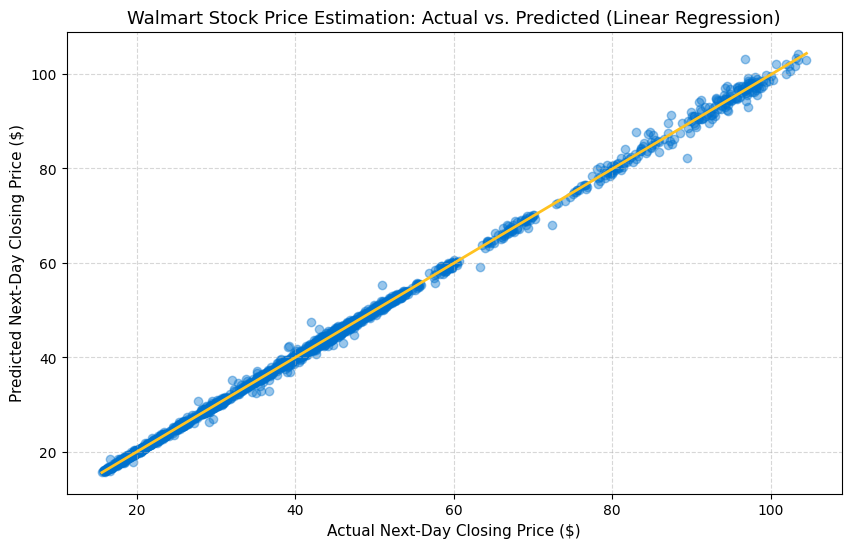

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import math

# 1. DATA LOADING & PREPROCESSING
file_path = '/content/Walmart_stock.csv'
df = pd.read_csv(file_path)

# Normalize column names
df.columns = df.columns.str.strip().str.capitalize()

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    df.set_index('Date', inplace=True)

# Feature Engineering
df['Daily_Return'] = df['Close'].pct_change()
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# Dependent Variable (Target) for Linear Regression: Next Day's Price
df['Next_Day_Close_Price'] = df['Close'].shift(-1)

# Drop missing values
df.dropna(inplace=True)

# 2. MODEL TRAINING
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'MA_20', 'MA_50']
X = df[features]
y = df['Next_Day_Close_Price']

# 80/20 Chronological Split
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)

# 3. EVALUATION METRICS
rmse = math.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("================ MODEL EVALUATION ================")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared (R^2) Score:         {r2:.4f}")
print("==================================================")

# 4. VISUALIZATION
plt.figure(figsize=(10, 6))

sns.regplot(x=y_test.values, y=predictions,
            scatter_kws={'alpha':0.4, 'color':'#0071CE'},
            line_kws={'color':'#FFC220', 'linewidth':2})

plt.title('Walmart Stock Price Estimation: Actual vs. Predicted (Linear Regression)', fontsize=13)
plt.xlabel('Actual Next-Day Closing Price ($)', fontsize=11)
plt.ylabel('Predicted Next-Day Closing Price ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Save image for GitHub repository
plt.savefig('visualization.png', dpi=300, bbox_inches='tight')
print("\nGraph generated and saved as 'visualization.png'!")
plt.show()